## High-Dimensional Data, Dimensionality Reduction & PCA  

### High-Dimensional Data
A dataset is said to be **high-dimensional** when it contains a very large number of features (columns/variables) compared to the number of observations (rows).  

#### Examples
- Low-dimensional data: 3 features such as Height, Weight, and Age.  
- High-dimensional data: 10,000 features such as gene expression levels for patients, image pixel values, or text embeddings.  

### What are High-Dimensional Spaces?

A `high-dimensional space` is simply the mathematical space where the data lives when it has many features (dimensions/variables).

- Each feature in the dataset represents a dimension (axis).
- A dataset with 2 features lives in a 2D space (you can plot it on a flat plane).
- A dataset with 3 features lives in a 3D space (you can visualize it as a cube).
- A dataset with 100 features lives in a 100-dimensional space (you cannot visualize this directly, but mathematically it exists).

### Problems of High-Dimensional Data (Curse of Dimensionality)

The Curse of Dimensionality is a critical challenge in machine learning, particularly as datasets grow in complexity with more features. 

In high-dimensional spaces, algorithms struggle to maintain accuracy, and data points become sparse, making it harder to identify meaningful patterns. 
1. **Sparsity of data**  
   - Data becomes more sparse as the number of dimensions increases. 
   - The dotted lines in the three-dimensional representation are to clarify the position of the points along the z-axis. 
   - Note the increasing empty space with increased dimensions.

   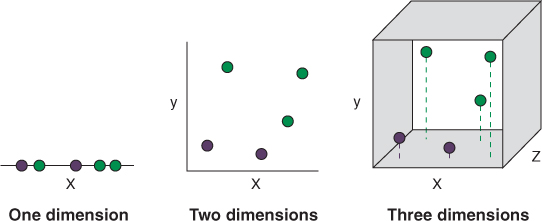

2. **Breakdown of distance measures**  
   - Algorithms such as k-Nearest Neighbors or clustering rely on distances between points.  
   - In high dimensions, distances between all points tend to become similar, reducing their usefulness.  

3. **Overfitting in models**  
   - As the number of features (dimensions) increases, the volume of the space grows exponentially, causing data points to become sparse.
   - This sparsity makes it difficult for machine learning algorithms to detect patterns effectively, leading to issues like overfitting.   
   - This reduces predictive performance on new data.  

4. **High computational cost**  
   - More features require more storage, more processing power, and longer training times.  

5. **Difficulty in visualization**  
   - Humans can only visualize data in two or three dimensions.  
   - Plotting data with more than three features requires dimensionality reduction.  

## Curse of Dimensionality in Machine Learning: How Can You Solve It?
### Dimensionality Reduction
`Dimensionality reduction` is the process of reducing the number of input variables in a dataset while retaining as much useful information as possible.  

### Why Dimensionality Reduction is Important
- Removes irrelevant or redundant features.  
- Helps to prevent overfitting by simplifying models.  
- Reduces computational requirements, making algorithms run faster.  
- Makes it possible to visualize high-dimensional data in 2D or 3D.  
- Improves the performance of distance-based algorithms by removing noise.  

## Approaches to Dimensionality Reduction

### A. Feature Selection
Feature selection reduces dimensionality by **choosing a subset of the original features**. It does not create new features.  

Methods:
- **Filter methods**: Select features based on statistical tests such as correlation, chi-square test, or ANOVA.  
- **Wrapper methods**: Use predictive models to evaluate subsets of features, e.g., forward selection, backward elimination, or recursive feature elimination (RFE).  
- **Embedded methods**: Select features as part of model training, e.g., LASSO regression, Decision Trees, or Random Forest feature importance.  

### B. Feature Extraction
Feature extraction reduces dimensionality by **transforming the original features into a new set of features**. These new features are usually fewer in number and more informative.  

Methods:
- **Principal Component Analysis (PCA)**: A linear method that finds new axes (principal components) which capture maximum variance in the data.  
- **Linear Discriminant Analysis (LDA)**: A supervised method that finds axes that maximize the separation between classes.  
- **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A nonlinear method for visualizing high-dimensional data in 2D or 3D.  
- **UMAP (Uniform Manifold Approximation and Projection)**: A nonlinear method that preserves both local and global structure in the data.  
- **Autoencoders**: Neural networks that learn to compress data into a lower-dimensional representation and reconstruct it back.  

## Principal Component Analysis (PCA)

### What is PCA?
PCA is a **dimensionality reduction technique** that takes many original features and transforms them into a smaller number of new features called **principal components**.  

The goal is to retain as much useful `variation` in the data as possible while reducing the number of dimensions.

Imagine we have a dataset containing information about customers applying for loans:

- Annual income (KES)
- Loan amount (KES)
- Monthly repayment (KES)

Notice that these features may be related. Customers with higher incomes may qualify for larger loans and have larger repayments.

This means some of the features contain overlapping information.

PCA attempts to combine such information into fewer dimensions.

PCA tries to find this direction of greatest variation.

### Understand what variance means

`Variance` measures how much values differ from their average.

For example, if all customers have almost the same income, income has low variance. If incomes vary widely, income has high variance.

In PCA, variance is important because it helps identify the directions in which the data varies the most.

### What are Principal Components?
- These components are **linear combinations of the original features**.  
- The components are constructed such that:  
  - **PC1** captures the maximum variance (the largest spread of the data).  
  - **PC2** captures the next largest variance, orthogonal (perpendicular) to PC1.  
  - **PC3, PC4, …** continue in the same way.  
- PCA is **unsupervised** because it does not use class labels. 
- A **principal component** is **not one of the original features**.  
- It is a **new variable**, formed as a **weighted sum of the original features**.  

Example (not actual Iris values):
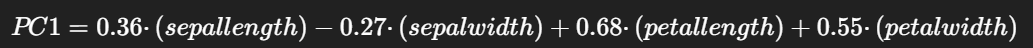

- The numbers `(0.36, -0.27, 0.68, 0.55)` are called loadings (eigenvector coefficients).
- They tell us how much each feature contributes to the component.

### Visualize the Data as Points

Suppose we only use two features: **annual income** and **loan amount**. Each customer becomes a point on a graph.

![Illustration: Customers vary mainly along a diagonal direction because income and loan amount tend to increase together.](image-illustration)

The points spread out mostly along the diagonal. PCA tries to find this direction of greatest variation.

### Center the Data

Before PCA is applied, the features are usually centered by subtracting their means.

For example:

* Mean annual income = KES 500,000.
* Mean loan amount = KES 200,000.

For Customer A:

* Centered income = 300,000 − 500,000 = −200,000.
* Centered loan amount = 100,000 − 200,000 = −100,000.

This shifts the data so that its center is at zero.

PCA is sensitive to the scale of the features. If features are measured in very different units or have very different magnitudes, you should generally standardize them before applying PCA.

### Find the Principal Directions

PCA searches for new directions through the data.

#### 1. First Principal Component (PC1)

The direction along which the data has the greatest variance.

#### 2. Second Principal Component (PC2)

A direction perpendicular to PC1 that captures the greatest remaining variance.

#### 3. Additional Components

Further perpendicular directions that capture the remaining variation, in decreasing order of importance.

For two features, PCA produces two principal components. For 800 original numerical features, it can produce up to 800 components, but you may retain only a smaller number.

### Transform the Original Features

Each principal component is a **weighted combination of the original features**.

For example, a component might look like:

$$
PC1 = 0.7(\text{Income}) + 0.7(\text{Loan Amount})
$$

This is only an illustrative formula. Actual PCA weights are calculated from the data.

The second component could be:

$$
PC2 = 0.7(\text{Income}) - 0.7(\text{Loan Amount})
$$

The first component captures information where income and loan amount increase together. The second captures differences between them.

The original features have now been transformed into new coordinates.

### Select Fewer Components

Suppose the you start with 800 features and PCA produces 800 principal components.

You should examine the **explained variance ratio** to determine how much variation each component captures.

### Illustrative Explained Variance

The numbers below are hypothetical

| Principal components    | Explained variance |
| ----------------------- | -----------------: |
| PC1                     |                35% |
| PC2                     |                20% |
| PC3                     |                15% |
| PC4–PC10                |                20% |
| Remaining components    |                10% |
| **First 10 components** |   **90% retained** |

If the first 10 components explain 90% of the total variance, you might reduce the dataset from 800 features to 10 components.

However, **90% explained variance does not mean 90% of loan-default prediction power is retained.** PCA is unsupervised: it does not use the default target when choosing components.


### Steps of the PCA Algorithm
1. **Standardize the data**  
   - Ensure each feature has a mean of 0 and variance of 1.  
   - This prevents features with large scales from dominating the analysis.  

2. **Compute the covariance matrix**  
   - The covariance matrix measures how features vary with respect to each other.  

3. **Find eigenvalues and eigenvectors of the covariance matrix**  
   - **Eigenvectors** represent the directions (principal components).  
   - **Eigenvalues** represent the importance of each component (amount of variance explained).  

4. **Rank components by eigenvalues**  
   - Sort the principal components in order of decreasing eigenvalues.  
   - The components with the largest eigenvalues carry the most information.  

5. **Select the top k components**  
   - Decide how many components to keep based on the cumulative variance explained (e.g., 95%).  

6. **Transform the data**  
   - Project the original dataset onto the selected principal components to obtain a lower-dimensional representation.  

### Example of PCA
- Original dataset has 100 features.  
- PCA analysis shows that 10 principal components explain 95% of the variance.  
- Instead of using all 100 features, the dataset can be reduced to 10 principal components, making it simpler and less prone to overfitting.  


### When should you consider PCA?

- When there are too many features: For example, a dataset has 800 numerical features, making the model complex and computationally expensive.

- When features are highly correlated: Several features may carry similar information. PCA combines them into fewer components.

- When overfitting is a concern: Reducing dimensions may help a model generalize better, although this is not guaranteed.

- When visualization is needed: PCA can reduce data to 2 or 3 dimensions to visualize patterns or clusters.

- When the model benefits from fewer features: Some algorithms, such as logistic regression or SVM, may benefit from a lower-dimensional representation.

### When might PCA not be the best choice?

- When the dataset has only a few relevant features.

- When interpretability is critical, such as explaining why a customer was denied a loan.

- When most features are categorical and have not been appropriately encoded.

- When feature selection can achieve the desired reduction while preserving meaningful business information.

### Real-World Example:

#### Facial Recognition (Eigenfaces)

- You have thousands of face images (e.g., security systems, photo tagging on social media).
- Each image might be 100×100=10,000 pixels → 10,000 features per face.
- That’s too high-dimensional and inefficient for storage + computation.

### How PCA Helps

#### 1. Flatten the Images
- Each image is reshaped into a **10,000-dimensional vector**.  

#### 2. Apply PCA
- PCA finds the **principal components** (the directions that explain the most variance in faces).  
- Instead of storing all 10,000 pixels, we might only need the top **100 components**.  

#### 3. Reconstruct Faces
- With those 100 components (called **eigenfaces**), we can still reconstruct faces with high accuracy.  

#### 4. Recognition Task
- New face → project into PCA space → compare with stored projections.  
- This makes facial recognition **faster and more robust**. 

- PCA “learns” the main features that vary across faces:
    - Eye position
    - Nose shape
    - Mouth width
    - Head orientation
- So instead of memorizing every pixel, PCA compresses the dataset into a smaller set of meaningful features.

### Python Code to Mitigate the Curse of Dimensionality:

####  Import Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

#### Load the Dataset

In [14]:
# Load the Iris dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [15]:
# Display the first few rows
print("First 5 rows of the dataset:")
print(X.head())

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [16]:
X.shape

(150, 4)

#### Split the Data and Standardize

Split the data into training and testing sets and standardize the features to ensure all variables contribute equally to the analysis.

In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Fit PCA (full) on training data and inspect explained variance

In [17]:
# fit PCA with all components (so we can inspect explained variance)
pca_full = PCA()                        # n_components=None -> all components
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
print("Explained variance ratio (per PC):", np.round(explained_var, 4))
print("Cumulative explained variance:", np.round(np.cumsum(explained_var), 4))


Explained variance ratio (per PC): [0.7255 0.23   0.0396 0.0049]
Cumulative explained variance: [0.7255 0.9555 0.9951 1.    ]


- `Explained variance` ratio per PC = proportion of the dataset’s information (variance) captured by each principal component.
- `Cumulative explained` variance = running total, showing how much variance is captured if we keep the first k components.

- PC1 (72.55%)
    - Captures most of the variance in the dataset.
    - This means a single axis (linear combination of features) already describes ~73% of the differences among Iris flowers.

- PC2 (23.00%)
    - Adds another ~23% of variance.
    - Together, PC1 + PC2 explain 95.55% of the variance, that’s why 2D PCA works so well for Iris visualization.

- PC3 (3.96%)
    - Adds very little, almost negligible new information.

- PC4 (0.49%)
    - Captures almost nothing (essentially noise).

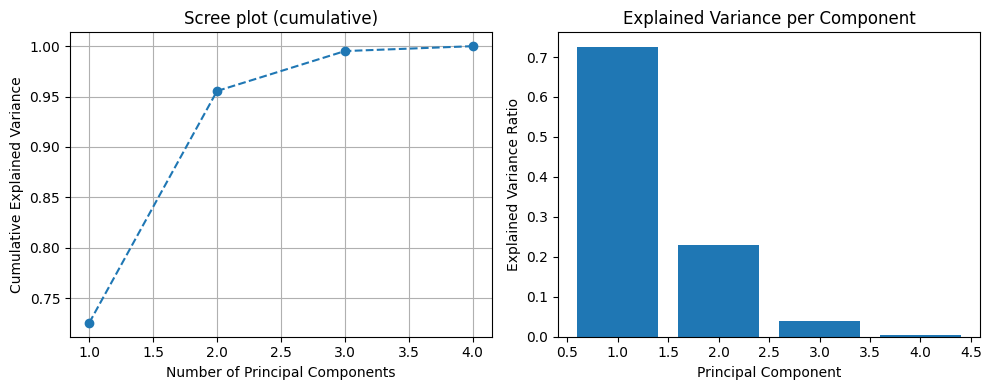

In [ ]:
# scree & bar plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(np.arange(1, len(explained_var)+1), np.cumsum(explained_var),
         marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree plot (cumulative)')
plt.grid(True)

plt.subplot(1,2,2)
plt.bar(np.arange(1, len(explained_var)+1), explained_var)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance per Component')

plt.tight_layout()
plt.show()


In [ ]:
#choose number of components to retain 95% variance
threshold = 0.95
cumvar = np.cumsum(explained_var)
n_needed = np.argmax(cumvar >= threshold) + 1
print(f"Number of components to retain >= {threshold*100:.0f}% variance: {n_needed}")


Number of components to retain >= 95% variance: 2


In [ ]:
# fit PCA with chosen number of components 
n_components = n_needed  
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)  # fit on train
X_test_pca  = pca.transform(X_test_scaled)       # transform test


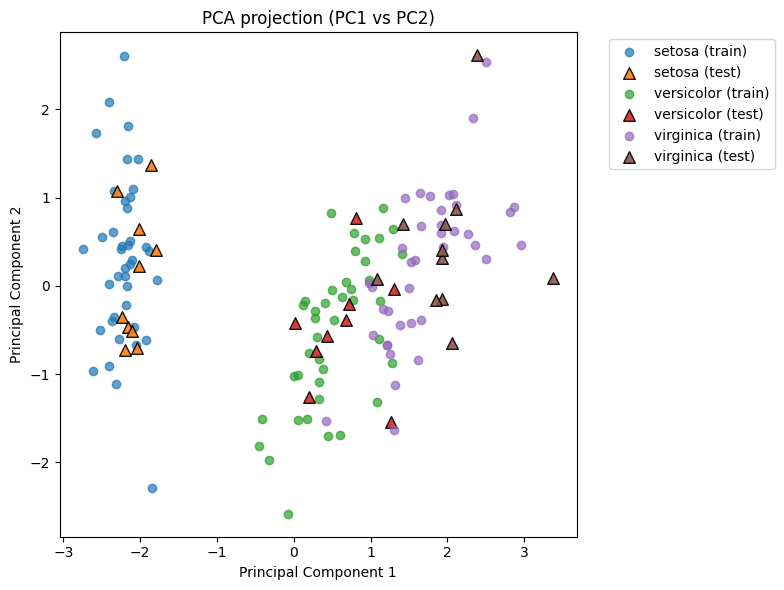

In [ ]:
# 2D scatter of first two principal components
if n_components >= 2:
    plt.figure(figsize=(8,6))
    for cls, name in enumerate(data.target_names):
        # train points for this class
        idx_train = (y_train == cls).to_numpy()
        plt.scatter(X_train_pca[idx_train, 0], X_train_pca[idx_train, 1],
                    marker='o', alpha=0.7, label=f"{name} (train)")

        # test points for this class
        idx_test = (y_test == cls).to_numpy()
        plt.scatter(X_test_pca[idx_test, 0], X_test_pca[idx_test, 1],
                    marker='^', edgecolors='k', s=70, alpha=0.9, label=f"{name} (test)")

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA projection (PC1 vs PC2)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # put legend to the right
    plt.tight_layout()
    plt.show()
else:
    print("n_components < 2 — no 2D scatter to show.")


In [ ]:
# pipeline example (scaling + PCA + classifier) - fit only on training data
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

pipe = make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression(random_state=42))
pipe.fit(X_train, y_train)                  # pipeline fits scaler+PCA on train internally
y_pred = pipe.predict(X_test)
print("Test accuracy (pipeline w/ PCA(2)):", accuracy_score(y_test, y_pred))


Test accuracy (pipeline w/ PCA(2)): 0.9


## Facial Recognition using PCA and K-Nearest Neighbors

### Importing Libraries

In [ ]:
# Core scientific libraries
import numpy as np
import matplotlib.pyplot as plt

# Data handling
from sklearn.datasets import fetch_lfw_people 

# Preprocessing & dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler  # if not using whiten=True

# Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Visualization 
import seaborn as sns   # for heatmaps and enhanced plots
import matplotlib.pyplot as plt

### Load dataset

In [29]:
# Load the LFW dataset with faces having at least 60 images
faces = fetch_lfw_people(min_faces_per_person=60, resize=0.4)
X, y = faces.data, faces.target
images = faces.images
target_names = faces.target_names

### Understanding the data

In [30]:
# Display shape information
dataset_info = {
    "X_shape": X.shape,
    "image_shape": images[0].shape,
    "num_classes": len(target_names)
}
dataset_info

{'X_shape': (1348, 1850), 'image_shape': (50, 37), 'num_classes': 8}

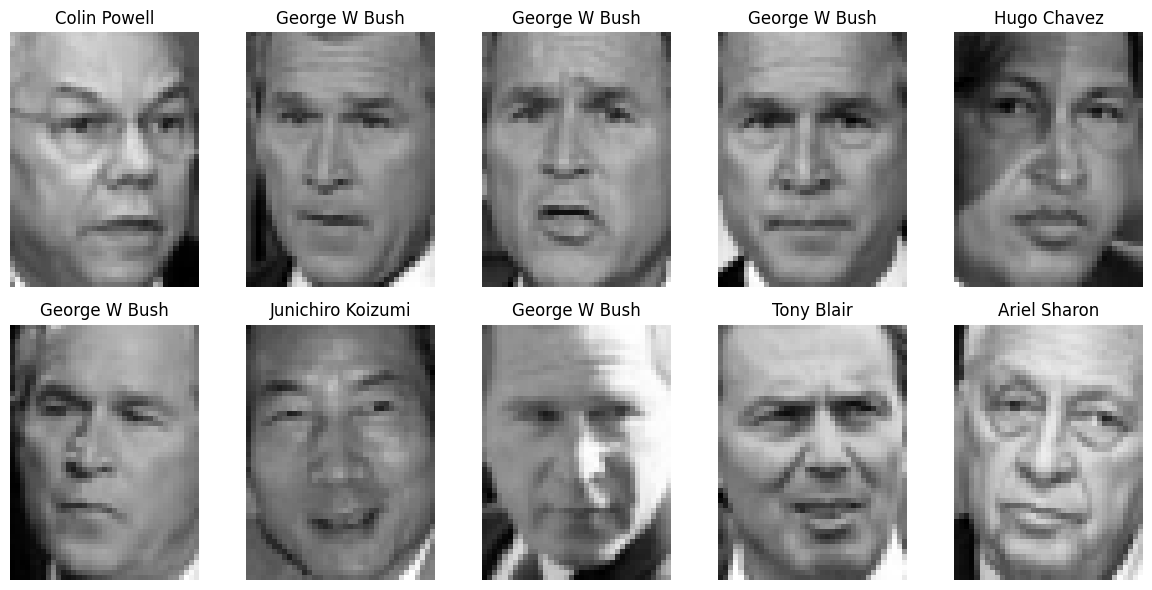

In [31]:
# Show the first few faces
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(target_names[y[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

#### People being recognized

In [32]:
print("People being recognized:")
for i, name in enumerate(target_names):
    print(f"{i}: {name}")

People being recognized:
0: Ariel Sharon
1: Colin Powell
2: Donald Rumsfeld
3: George W Bush
4: Gerhard Schroeder
5: Hugo Chavez
6: Junichiro Koizumi
7: Tony Blair


#### Sample faces of the people being recognized

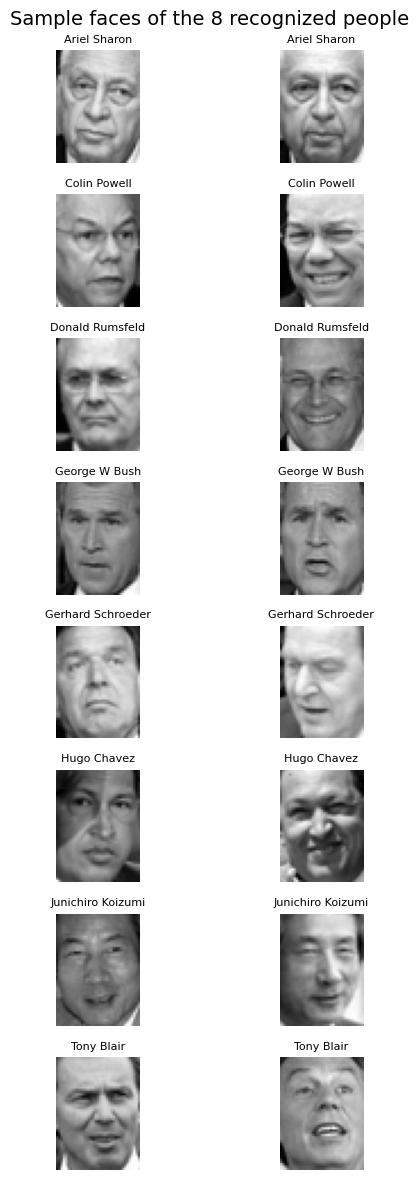

In [33]:
# Plot first 2 faces for each person
fig, axes = plt.subplots(len(target_names), 2, figsize=(6, 12))

for person_id, person_name in enumerate(target_names):
    # Find indices of images belonging to this person
    person_idx = np.where(y == person_id)[0][:2]  # take first 2
    for j, idx in enumerate(person_idx):
        ax = axes[person_id, j]
        ax.imshow(images[idx], cmap="gray")
        ax.set_title(person_name, fontsize=8)
        ax.axis("off")

plt.suptitle("Sample faces of the 8 recognized people", fontsize=14)
plt.tight_layout()
plt.show()


### Apply PCA to Face Dataset
We reduce dimensionality to 100 principal components using randomized SVD and whitening.

In [10]:
from sklearn.decomposition import PCA

# Step 1: Initialize PCA (keep 100 components for example)
pca = PCA(n_components=100, svd_solver='randomized', whiten=True)

# Step 2: Fit PCA on the face dataset
X_pca = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_pca.shape)

Original shape: (1348, 1850)
Transformed shape: (1348, 100)


`whiten=True:` scales the components so they have unit variance. This helps some models (like KNN) perform better, because all components contribute equally.

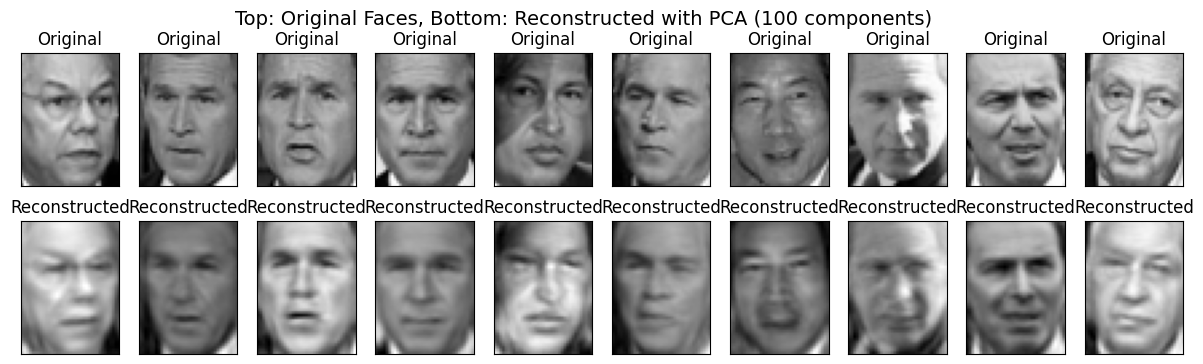

In [11]:
# Step 3: Reconstruct some faces from PCA components
X_reconstructed = pca.inverse_transform(X_pca)

# Show a comparison of original vs reconstructed faces
fig, axes = plt.subplots(2, 10, figsize=(15, 4),
                         subplot_kw={'xticks':[], 'yticks':[]})

for i in range(10):
    # Original
    axes[0, i].imshow(images[i], cmap="gray")
    axes[0, i].set_title("Original")

    # Reconstructed
    axes[1, i].imshow(X_reconstructed[i].reshape(images[0].shape), cmap="gray")
    axes[1, i].set_title("Reconstructed")

plt.suptitle("Top: Original Faces, Bottom: Reconstructed with PCA (100 components)", fontsize=14)
plt.show()

#### inspect PCA: explained variance + top eigenfaces

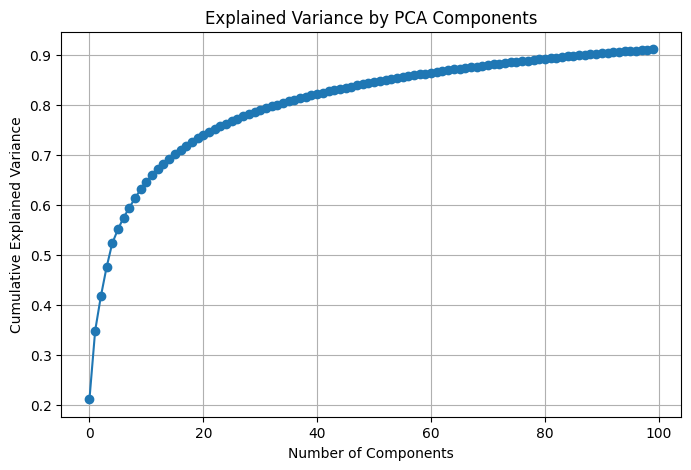

In [17]:
# Explained variance ratio (how much info each PC keeps)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(explained_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

#### Visualize Eigenfaces

Each principal component can be reshaped back into the image size → these are called eigenfaces.

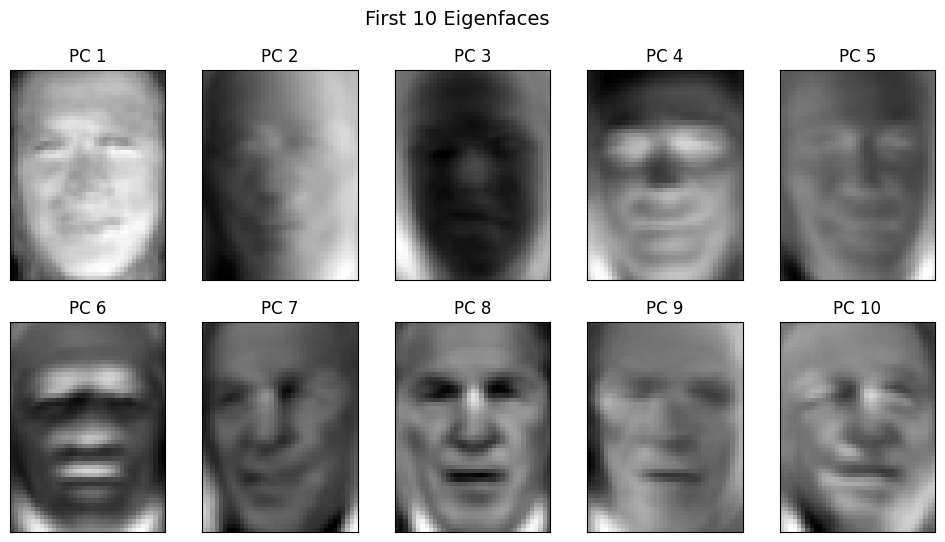

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6),
                         subplot_kw={'xticks':[], 'yticks':[]})

for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(images[0].shape), cmap="gray")
    ax.set_title(f"PC {i+1}")

plt.suptitle("First 10 Eigenfaces", fontsize=14)
plt.show()

### Modelling using KNN

In [19]:
# Baseline KNN in PCA space (proper: PCA fitted on train only)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [20]:
# 1) Train/test split (stratified)
X_train, X_test, y_train, y_test, imgs_train, imgs_test = train_test_split(
    X, y, images, test_size=0.20, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (1078, 1850) Test shape: (270, 1850)


In [22]:
# 2) Fit PCA on training set only
n_components = 100
pca_train = PCA(n_components=n_components, svd_solver='randomized', whiten=True, random_state=42)
X_train_pca = pca_train.fit_transform(X_train)
X_test_pca = pca_train.transform(X_test)

print("PCA fitted on train. Shapes ->", X_train_pca.shape, X_test_pca.shape)

PCA fitted on train. Shapes -> (1078, 100) (270, 100)


In [23]:
# 3) Train baseline KNN (k=5)
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn.fit(X_train_pca, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
# 4) Predict & evaluate
y_pred = knn.predict(X_test_pca)
acc = accuracy_score(y_test, y_pred)
print(f"Baseline KNN accuracy (k=5) in PCA space: {acc:.4f}\n")
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Baseline KNN accuracy (k=5) in PCA space: 0.6630

Classification report:

                   precision    recall  f1-score   support

     Ariel Sharon       0.43      0.38      0.40        16
     Colin Powell       0.73      0.77      0.75        47
  Donald Rumsfeld       0.54      0.29      0.38        24
    George W Bush       0.64      0.93      0.76       106
Gerhard Schroeder       0.71      0.23      0.34        22
      Hugo Chavez       0.88      0.50      0.64        14
Junichiro Koizumi       0.88      0.58      0.70        12
       Tony Blair       0.71      0.41      0.52        29

         accuracy                           0.66       270
        macro avg       0.69      0.51      0.56       270
     weighted avg       0.67      0.66      0.64       270



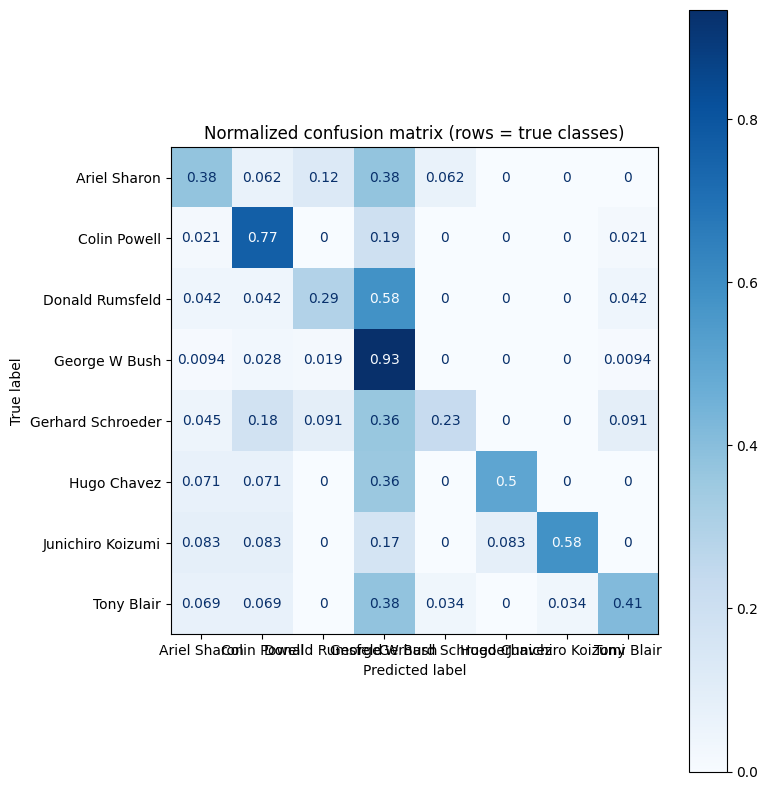

In [25]:
# 5) Confusion matrix (normalized by true class)
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title("Normalized confusion matrix (rows = true classes)")
plt.tight_layout()
plt.show()

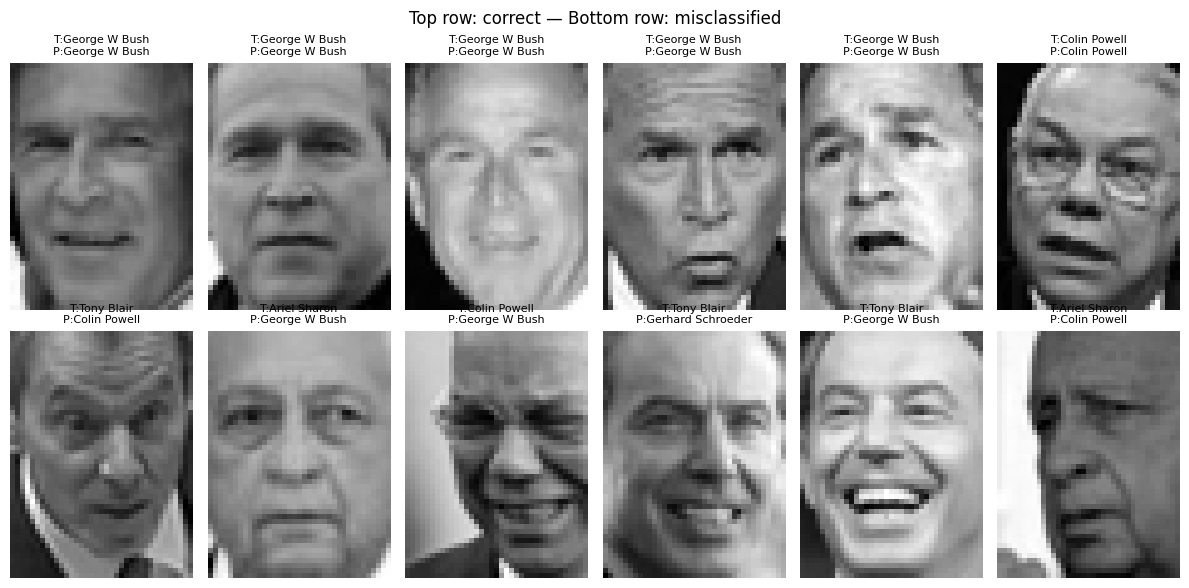

In [26]:
# 6) Show some correct vs misclassified examples
correct_idxs = np.where(y_pred == y_test)[0]
wrong_idxs   = np.where(y_pred != y_test)[0]

n_show = min(6, len(correct_idxs), len(wrong_idxs))
plt.figure(figsize=(12, 6))
for i in range(n_show):
    idx = correct_idxs[i]
    ax = plt.subplot(2, n_show, i+1)
    ax.imshow(imgs_test[idx], cmap='gray'); ax.axis('off')
    ax.set_title(f"T:{target_names[y_test[idx]]}\nP:{target_names[y_pred[idx]]}", fontsize=8)

for i in range(n_show):
    idx = wrong_idxs[i]
    ax = plt.subplot(2, n_show, n_show + i + 1)
    ax.imshow(imgs_test[idx], cmap='gray'); ax.axis('off')
    ax.set_title(f"T:{target_names[y_test[idx]]}\nP:{target_names[y_pred[idx]]}", fontsize=8)

plt.suptitle("Top row: correct — Bottom row: misclassified")
plt.tight_layout()
plt.show()

### Incremental PCA

Incremental principal component analysis (IPCA) is typically used as a replacement for principal component analysis (PCA) when the dataset to be decomposed is too large to fit in memory. 

Instead of computing `PCA` on the entire dataset at once, `IPCA` processes the data in mini-batches (chunks) and incrementally updates the principal components.

### Why use Incremental PCA?

- Standard PCA requires loading the full dataset into memory to compute the covariance matrix and perform SVD.
- For very large datasets (e.g., millions of samples, high-dimensional images), this becomes impossible.
- IPCA avoids memory issues by:
    - Splitting data into smaller chunks.
    - Updating the decomposition incrementally.

### Examples of Incremental PCA (IPCA)

#### Face Recognition on Large Image Datasets
- Datasets like **LFW (Labeled Faces in the Wild)** or company security camera logs can have **millions of face images**.  
- Each image (say 100×100 pixels) = 10,000 features. With millions of images, that’s **terabytes of data**.  
- **Challenge:** Regular PCA can’t load all images into memory at once.  
- **Solution:** Use **Incremental PCA**:  
  - Load a few thousand images at a time.  
  - Update the PCA components batch by batch.  
  - Reduce image dimensions before applying classification (e.g., SVM, KNN) for face recognition.  

#### Credit Card Fraud Detection
- Banks process **billions of transactions daily**.  
- Each transaction has many features (amount, time, location, merchant type, device ID, etc.).  
- **Challenge:** Data is too big for in-memory PCA.  
- **Solution:** IPCA reduces dimensionality batch by batch, making the data manageable for anomaly detection algorithms.  

#### Medical Imaging (MRI/CT Scans)
- Hospitals store massive amounts of **MRI or CT scan images** (each scan can be 3D and high-resolution).  
- Researchers use PCA for compression/feature extraction.  
- **Challenge:** Too many images to load at once.  
- **Solution:** IPCA processes scans incrementally, extracting key features for diagnosis or research.  


### IPCA Example

#### Importing Libraries

In [54]:
from sklearn.decomposition import IncrementalPCA
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Train/test split
from sklearn.model_selection import train_test_split

In [36]:
# Load dataset
digits = load_digits()
X = digits.data      
y = digits.target

#### Dataset shape and structure

In [38]:
print("X shape:", X.shape)   # features
print("y shape:", y.shape)   # labels
print("Image shape:", digits.images[0].shape)

X shape: (1797, 64)
y shape: (1797,)
Image shape: (8, 8)


In [40]:
print("Labels:", y[:20])

Labels: [0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9]


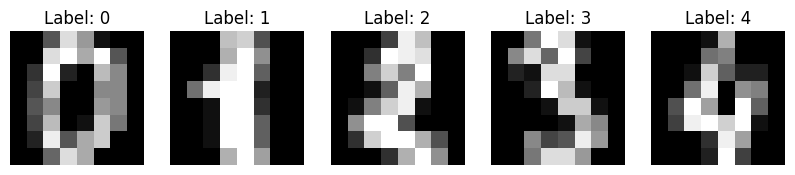

In [41]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.show()

#### Distribution of digits (class balance)

In [ ]:
unique, counts = np.unique(y, return_counts=True)
digit_distribution = dict(zip(unique, counts))
print(digit_distribution)

{np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181), np.int64(5): np.int64(182), np.int64(6): np.int64(181), np.int64(7): np.int64(179), np.int64(8): np.int64(174), np.int64(9): np.int64(180)}


#### Standardize the data

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Apply Incremental PCA (IPCA)

In [45]:
# Initialize IPCA
ipca = IncrementalPCA(n_components=20, batch_size=200)

# Fit and transform
X_ipca = ipca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_ipca.shape)

Original shape: (1797, 64)
Reduced shape: (1797, 20)


- `batch_size=200` - IPCA will process the data in mini-batches of 200 samples at a time, updating the PCA model incrementally.
    - This is useful when the dataset is too big to fit into memory at once.
    - In our digits case (small dataset), it’s not required, but we use it to simulate how IPCA works on large data.

- `fit_transform` does two things:
    - fit - learns the principal components (the directions of maximum variance in the data).
    - transform - projects each sample in X_scaled into the new reduced space of 20 components.

#### Variance explained by IPCA components

Each principal component captures some proportion of the total variance (information) in the data.

In [46]:
# Variance explained by each component
explained_variance = ipca.explained_variance_ratio_

# Print first 10 components
print("Explained variance ratio (first 10 components):")
print(explained_variance[:10])

# Cumulative variance explained
cumulative_variance = np.cumsum(explained_variance)
print("\nCumulative variance explained:")
print(cumulative_variance)

Explained variance ratio (first 10 components):
[0.1202542  0.09555648 0.08438927 0.06492987 0.04845195 0.04182402
 0.03924318 0.03348388 0.02960566 0.02828086]

Cumulative variance explained:
[0.1202542  0.21581068 0.30019994 0.36512981 0.41358176 0.45540578
 0.49464895 0.52813284 0.5577385  0.58601936 0.61351782 0.63845663
 0.66046305 0.68216295 0.70278036 0.72067326 0.73795212 0.75354218
 0.76834338 0.78111306]


- `Explained variance ratio` = “How much info does each individual component hold?”
    - The first component explains 0.1202542 ≈ 12.0% of the variance.
    - The second component explains 9.6%.
    - The third component explains 8.4%.

- `Cumulative variance explained` = “How much info do we retain if we keep the first k components?”
    - First component alone → explains 12%.
    - First two components together → 21.6%.
    - First three → 30%.
    - First 10 → 58.6%.

### Scree Plot (Cumulative Variance)

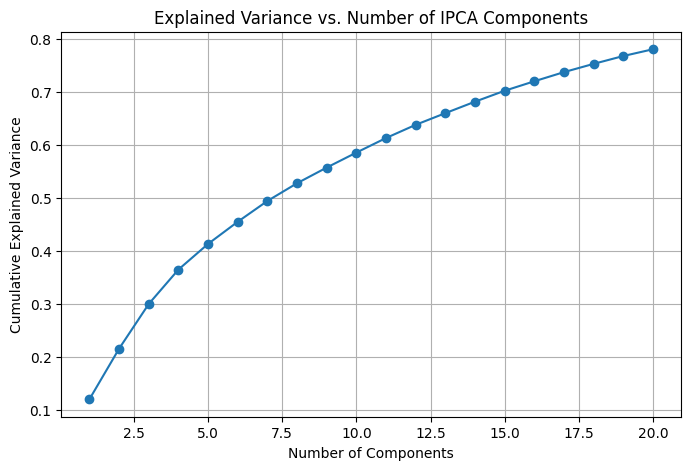

In [47]:
# Get variance info
explained_variance = ipca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of IPCA Components")
plt.grid(True)
plt.show()

### Scatter Plot of Digits in 2D (IPCA)

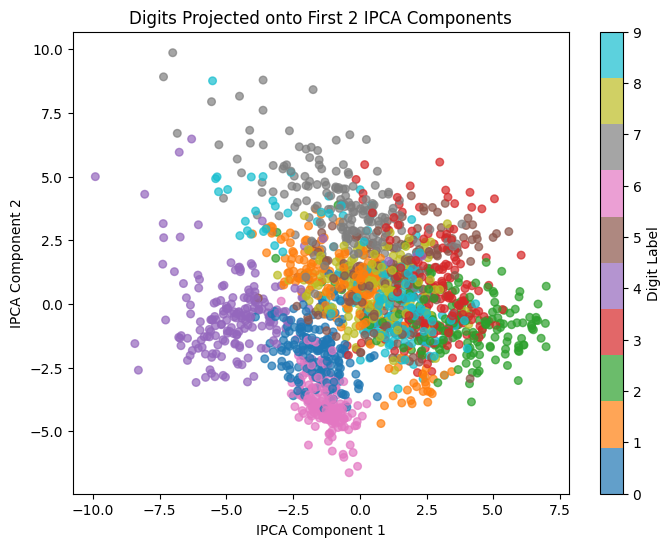

In [48]:
plt.figure(figsize=(8,6))
plt.scatter(X_ipca[:, 0], X_ipca[:, 1], 
            c=y, cmap='tab10', alpha=0.7, s=30)
plt.colorbar(label="Digit Label")
plt.xlabel("IPCA Component 1")
plt.ylabel("IPCA Component 2")
plt.title("Digits Projected onto First 2 IPCA Components")
plt.show()


### Reconstruct images from the reduced components (original vs reconstructed digits)

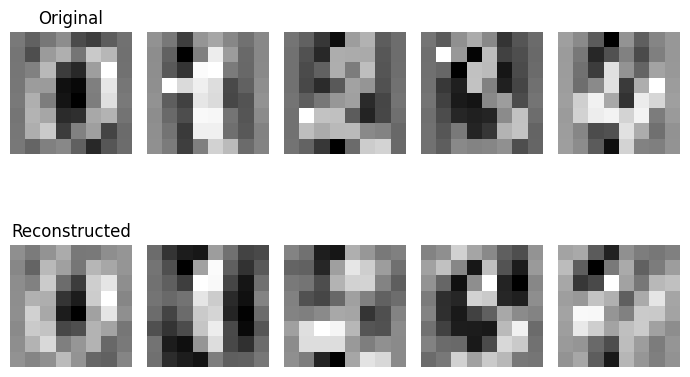

In [53]:
# Reconstruct images
X_reconstructed = ipca.inverse_transform(X_ipca)

# Plot original vs reconstructed for first 5 samples
fig, axes = plt.subplots(2, 5, figsize=(7, 5))

for i in range(5):
    # Original
    axes[0, i].imshow(X_scaled[i].reshape(8, 8), cmap='gray')
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original")

    # Reconstructed
    axes[1, i].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstructed")

plt.tight_layout()
plt.show()


### Train a Classifier on IPCA Features

We’ll use Logistic Regression (simple and effective for digit recognition).

Accuracy on test set: 0.9472222222222222


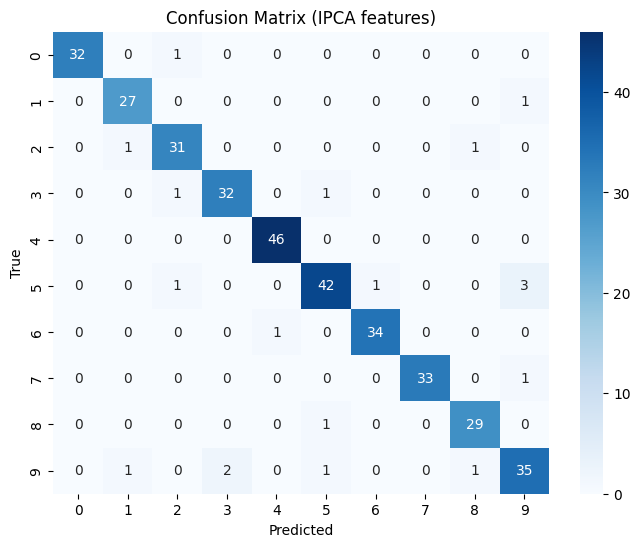

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_ipca, y, test_size=0.2, random_state=42)

# Train classifier
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy on test set:", acc)

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (IPCA features)")
plt.show()